# Lab 4: Data Quality Assessment & Preprocessing (Housing Dataset)

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model to predict house prices, we must clean and prepare the data properly.


In this lab, we will apply practical preprocessing techniques step by step using the Housing dataset.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [ ]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 2. Data Quality Assessment
### 2.1 Check Data Types
[cite_start]Data types must match the real meaning of each column[cite: 1].
[cite_start]For example, `price` and `area` should be numeric, while categorical features like `mainroad` or `furnishingstatus` should be strings or boolean/categorical types[cite: 1].

In [ ]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


[cite_start]We observe that `price` and `area` are already correctly stored as `int64`[cite: 1]. [cite_start]However, many features like `mainroad`, `guestroom`, and `basement` are stored as `object` (strings 'yes'/'no')[cite: 1].

### 2.2 Convert Incorrect Data Types
For machine learning models to work effectively, it's often best to map binary string categories ('yes'/'no') into numeric/boolean representations (1/0). Let's convert the `mainroad` and `airconditioning` columns as an example.

In [ ]:
binary_columns = ['mainroad', 'airconditioning']
for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,object
basement,object
hotwaterheating,object
airconditioning,int64


## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [ ]:
df.isna().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our housing dataset is completely clean with no missing values, we will introduce artificial ones into the `price` column *for learning purposes*.

In [ ]:
df_missing = df.copy()
df_missing.loc[0:5, 'price'] = np.nan
df_missing.isna().sum()

,0
price,6
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
print("Original shape: ", df.shape)
print("After removing some values: ", df_missing.shape)
df_missing.head(10)

Original shape:  (545, 13)
After removing some values:  (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,NaN,7420,4,2,3,1,no,no,no,1,2,yes,furnished
1,NaN,8960,4,4,4,1,no,no,no,1,3,no,furnished
2,NaN,9960,3,2,2,1,no,yes,no,0,2,yes,semi-furnished
3,NaN,7500,4,2,2,1,no,yes,no,1,3,yes,furnished
4,NaN,7420,4,1,2,1,yes,yes,no,1,2,no,furnished
5,NaN,7500,3,3,1,1,no,yes,no,1,2,yes,semi-furnished
6,10150000.0,8580,4,3,4,1,no,no,no,1,2,yes,semi-furnished
7,10150000.0,16200,5,3,2,1,no,no,no,0,0,no,unfurnished
8,9870000.0,8100,4,1,2,1,yes,yes,no,1,2,yes,furnished
9,9800000.0,5750,3,2,4,1,yes,no,no,1,1,yes,unfurnished


### Strategy 1: Remove Records
This strategy removes records containing missing data. It works well if the number of missing rows is very small compared to the total dataset.

In [ ]:
df_removed = df_missing.dropna()
print("Shape after dropping NaNs:", df_removed.shape)

Shape after dropping NaNs: (539, 13)


### Strategy 2: Mean Imputation


The mean represents the average value. It is commonly used for normally distributed data.

In [ ]:
df_imputed_mean = df_missing.copy()
df_imputed_mean['price'] = df_imputed_mean['price'].fillna(df_imputed_mean['price'].mean())

df_imputed_mean.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4.685700e+06,7420,4,2,3,1,no,no,no,1,2,yes,furnished
1,4.685700e+06,8960,4,4,4,1,no,no,no,1,3,no,furnished
2,4.685700e+06,9960,3,2,2,1,no,yes,no,0,2,yes,semi-furnished
3,4.685700e+06,7500,4,2,2,1,no,yes,no,1,3,yes,furnished
4,4.685700e+06,7420,4,1,2,1,yes,yes,no,1,2,no,furnished
5,4.685700e+06,7500,3,3,1,1,no,yes,no,1,2,yes,semi-furnished
6,1.015000e+07,8580,4,3,4,1,no,no,no,1,2,yes,semi-furnished
7,1.015000e+07,16200,5,3,2,1,no,no,no,0,0,no,unfurnished
8,9.870000e+06,8100,4,1,2,1,yes,yes,no,1,2,yes,furnished
9,9.800000e+06,5750,3,2,4,1,yes,no,no,1,1,yes,unfurnished


Missing values are now replaced with the average house price. Mean imputation is sensitive to outliers, which are common in real estate data.

### Strategy 3: Median Imputation


The median is more robust to extreme house prices (outliers) than the mean. It is preferred for skewed data like income or housing prices.

#### Why Median Imputation?
For this housing dataset, **Median Imputation** is the most appropriate strategy.

In real estate, variables like `price` and `area` are rarely normally distributed; they are typically heavily right-skewed. While there is a limit to how cheap a house can be, there is no upper limit. A small number of multi-million dollar luxury homes (outliers) will artificially drag the mathematical average (mean) much higher.



Because the median represents the exact 50th percentile of the data, it is completely robust to extreme outliers. By filling missing values with the median, we ensure we are inserting a truly "typical" house price, which protects the accuracy of our future machine learning models.

In [ ]:
df_imputed_median = df_missing.copy()
df_imputed_median['price'] = df_imputed_median['price'].fillna(df_imputed_median['price'].median())

df_imputed_median.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4319000.0,7420,4,2,3,1,no,no,no,1,2,yes,furnished
1,4319000.0,8960,4,4,4,1,no,no,no,1,3,no,furnished
2,4319000.0,9960,3,2,2,1,no,yes,no,0,2,yes,semi-furnished
3,4319000.0,7500,4,2,2,1,no,yes,no,1,3,yes,furnished
4,4319000.0,7420,4,1,2,1,yes,yes,no,1,2,no,furnished
5,4319000.0,7500,3,3,1,1,no,yes,no,1,2,yes,semi-furnished
6,10150000.0,8580,4,3,4,1,no,no,no,1,2,yes,semi-furnished
7,10150000.0,16200,5,3,2,1,no,no,no,0,0,no,unfurnished
8,9870000.0,8100,4,1,2,1,yes,yes,no,1,2,yes,furnished
9,9800000.0,5750,3,2,4,1,yes,no,no,1,1,yes,unfurnished


## 4. Handling Outliers
Outliers are extreme values that can distort models (like a multi-million dollar mansion in a normal neighborhood). We will detect outliers in the `price` column using the IQR method.

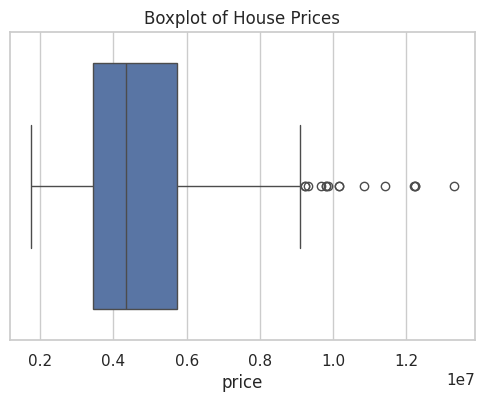

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Boxplot of House Prices")
plt.show()

Points outside the right whisker represent exceptionally expensive houses (potential outliers).

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**
The IQR method defines outliers as values outside `Q1 - 1.5×IQR` and `Q3 + 1.5×IQR`.

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,no,no,no,1,2,yes,furnished
1,12250000,8960,4,4,4,1,no,no,no,1,3,no,furnished
2,12250000,9960,3,2,2,1,no,yes,no,0,2,yes,semi-furnished
3,12215000,7500,4,2,2,1,no,yes,no,1,3,yes,furnished
4,11410000,7420,4,1,2,1,yes,yes,no,1,2,no,furnished


### Strategy 1: Remove Outliers
We remove values outside the acceptable range. Keep in mind that for real estate, a high price might just be a luxury home, not necessarily a data error.

In [ ]:
df_no_outliers = df[(df['price'] >= lower) & (df['price'] <= upper)]
print("Original shape: ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (545, 13)
After removing outliers:  (530, 13)


### Strategy 2: Capping Outliers (Percentile Method)
Instead of removing luxury homes, we can replace extreme values with a hard percentile limit (e.g., capping at the 95th percentile).

In [ ]:
lower_cap = df['price'].quantile(0.05)
upper_cap = df['price'].quantile(0.95)

df_capped = df.copy()
df_capped['price'] = df_capped['price'].clip(lower_cap, upper_cap)

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range. Without it, `price` (in millions) would completely overpower `area` (in thousands) in distance-based algorithms like KNN.

### Min-Max Normalization
Rescales values to a fixed range, usually 0 to 1.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['price', 'area']].copy()

df_scaled[['price', 'area']] = scaler.fit_transform(df_scaled)
df_scaled.head()

,price,area
0,1.000000,0.396564
1,0.909091,0.502405
2,0.909091,0.571134
3,0.906061,0.402062
4,0.836364,0.396564


### Z-Score Normalization
Transforms the data so the mean is 0 and the standard deviation is 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['price', 'area']].copy()

df_standardized[['price', 'area']] = scaler.fit_transform(df_standardized)
df_standardized.head()

,price,area
0,4.566365,1.046726
1,4.004484,1.757010
2,4.004484,2.218232
3,3.985755,1.083624
4,3.554979,1.046726


## Check Correlation Before Applying PCA
We will check whether `price` and `area` are correlated. If they are, they contain overlapping information, making dimensionality reduction meaningful.

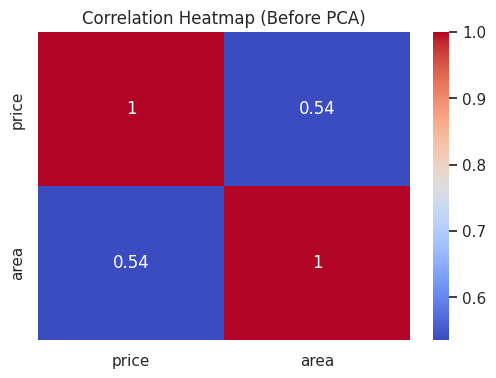

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['price','area']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

A positive correlation indicates that as `area` increases, `price` tends to increase. Because they share a linear relationship, we can use PCA to combine them.

## 6. Data Reduction – Principal Component Analysis (PCA)
PCA reduces dimensionality while retaining most of the important variance. We will combine our two correlated features (`price` and `area`) into principal components.

In [ ]:
from sklearn.decomposition import PCA

X = df_standardized[['price', 'area']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.76799867 0.23200133]


The first component (PC1) will capture the shared variance between price and area, while PC2 captures the residual noise.

### Visualizing the PCA Projection

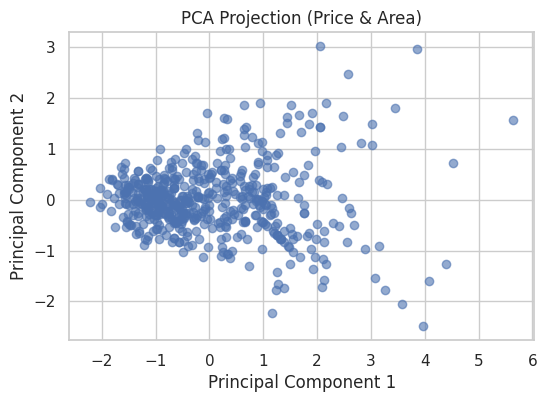

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.6, color='b')
plt.title("PCA Projection (Price & Area)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

#### Interpreting the PCA Results (Task 5)
Looking at the `explained_variance_ratio_` output from the code above, we can understand how much information each new component retains from the original dataset:

* **Principal Component 1 (PC1):** This component captures the vast majority of the variance in the data **(~76.8%)**. Because `price` and `area` have a strong positive correlation (as area increases, price generally increases), PC1 effectively represents this primary "size-to-value" relationship.
* **Principal Component 2 (PC2):** This component captures the small remaining variance **(~23.2%)**. It represents the residual noise and exceptions to the rule, such as smaller houses that are exceptionally expensive (perhaps due to premium locations or renovations) or large houses that are unusually cheap.

**Conclusion:** Because PC1 successfully captures almost all the meaningful, shared variance between `price` and `area`, we have successfully reduced two dimensions into a single feature without losing significant predictive power.